# Imports

In [ ]:
!pip install scanpy
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 967.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

file_path = "/content/drive/MyDrive/GP_datasets/PBMCs/1k_pbmcs_proc_subset.h5ad"
adata = sc.read_h5ad(file_path)

print(adata)


AnnData object with n_obs × n_vars = 1000 × 12000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_types', 'hvg'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'


In [ ]:
#drop other class
adata = adata[adata.obs["cell_type"] != "Other"].copy()
print(adata.obs["cell_type"].value_counts())
labels = adata.obs["cell_type"]
X = adata.X
print("Number of classes:", labels.nunique())

cell_type
CD4 T cells          383
CD14+ Monocytes      222
B cells              127
CD8 T cells          126
NK cells              36
FCGR3A+ Monocytes     31
Dendritic Cells       22
Megakaryocytes        10
Name: count, dtype: int64
Number of classes: 8


In [ ]:
labels

,cell_type
ACACCGGAGTGAATTG-1,CD14+ Monocytes
CGATTGATCGTAGGAG-1,CD14+ Monocytes
CCAGCGACACAACGCC-1,CD4 T cells
AATCGGTTCCGATATG-1,B cells
AGGGTGACAGTTTACG-1,B cells
...,...
CATGCCTTCTGCCCTA-1,NK cells
ATAAGAGCATTGAGCT-1,CD8 T cells
TGGTTCCAGTCGAGTG-1,CD4 T cells
AGTAGTCGTTAAGGGC-1,CD4 T cells


## Normalization

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Select HVG

seurat_v3 kanet btala3 error "install scikit-misc" after installation same error brdo

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor='seurat')
adata


AnnData object with n_obs × n_vars = 957 × 2000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'cell_types', 'hvg', 'log1p'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

In [ ]:
adata.var.head()


,gene_symbols,n_counts-0,n_counts-1,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,dispersions,dispersions_norm
HES4,HES4,580.0,294.0,855.0,True,189.0,0.197604,0.200353,2.573027,2.147004,0.992536
ISG15,ISG15,4014.0,1888.0,5705.0,True,269.0,1.202498,1.413837,2.089724,2.501310,1.046677
TNFRSF18,TNFRSF18,342.0,138.0,466.0,True,620.0,0.137802,0.060213,1.436345,2.079135,0.775867
TNFRSF4,TNFRSF4,475.0,228.0,694.0,True,525.0,0.247062,0.095907,1.518775,2.225669,1.243672
MMP23B,MMP23B,178.0,84.0,257.0,True,1586.0,0.104004,0.025481,1.105307,2.043550,0.662261


## PCA

In [ ]:
sc.tl.pca(adata, n_comps=100)
adata

AnnData object with n_obs × n_vars = 957 × 2000
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'cell_type'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm'
    uns: 'cell_types', 'hvg', 'log1p', 'pca'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc', 'X_pca'
    varm: 'PCs'

In [ ]:

y = labels.values

## Models

*   List item
*   List item



In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.X
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

### Evaluation

=== Logistic Regression ===
Accuracy: 0.9665621734587252
                   precision    recall  f1-score   support

          B cells       1.00      0.99      1.00       127
  CD14+ Monocytes       0.96      1.00      0.98       222
      CD4 T cells       0.96      0.99      0.97       383
      CD8 T cells       0.94      0.90      0.92       126
  Dendritic Cells       1.00      0.82      0.90        22
FCGR3A+ Monocytes       1.00      0.87      0.93        31
   Megakaryocytes       1.00      0.70      0.82        10
         NK cells       0.97      0.94      0.96        36

         accuracy                           0.97       957
        macro avg       0.98      0.90      0.94       957
     weighted avg       0.97      0.97      0.97       957



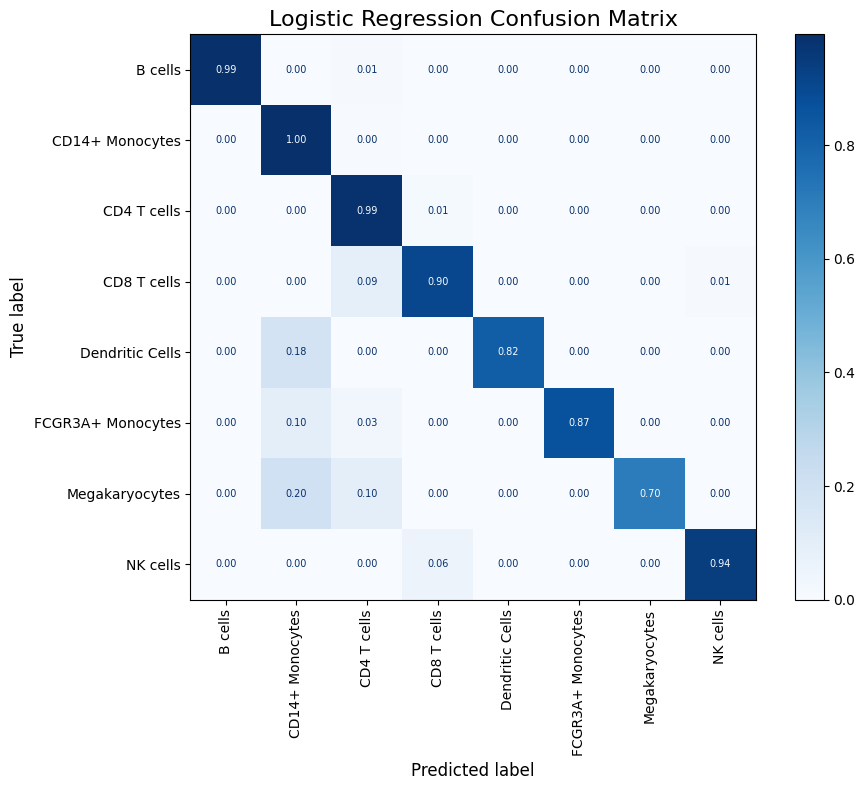


=== k-NN ===
Accuracy: 0.9613375130616509
                   precision    recall  f1-score   support

          B cells       1.00      0.99      1.00       127
  CD14+ Monocytes       0.94      1.00      0.97       222
      CD4 T cells       0.98      0.98      0.98       383
      CD8 T cells       0.92      0.95      0.93       126
  Dendritic Cells       0.82      0.82      0.82        22
FCGR3A+ Monocytes       1.00      0.87      0.93        31
   Megakaryocytes       0.00      0.00      0.00        10
         NK cells       1.00      0.92      0.96        36

         accuracy                           0.96       957
        macro avg       0.83      0.82      0.82       957
     weighted avg       0.95      0.96      0.96       957



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


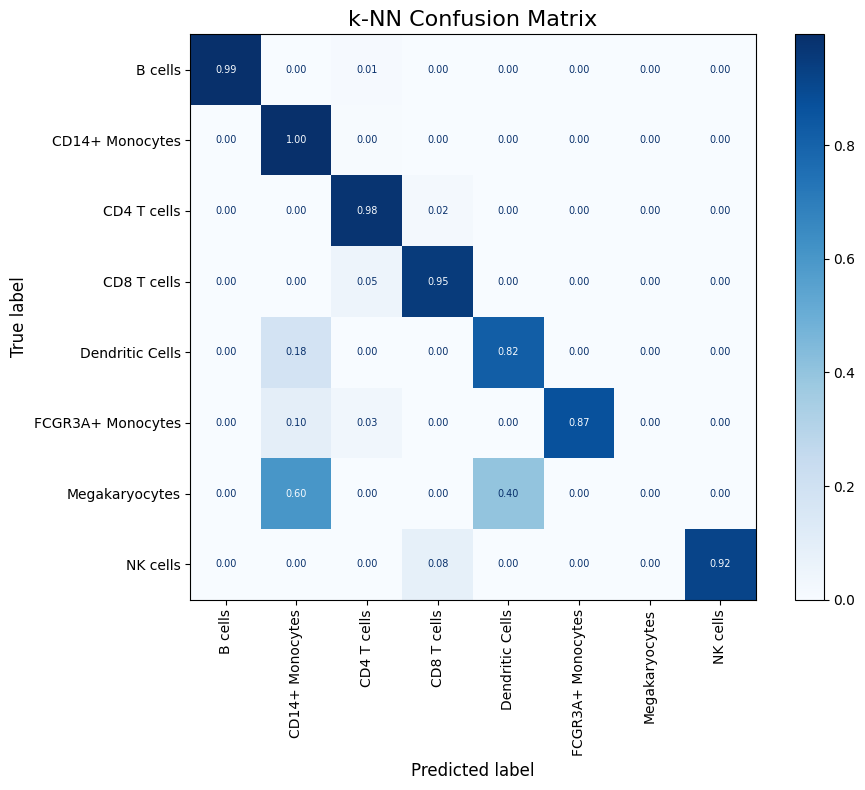

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")

print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

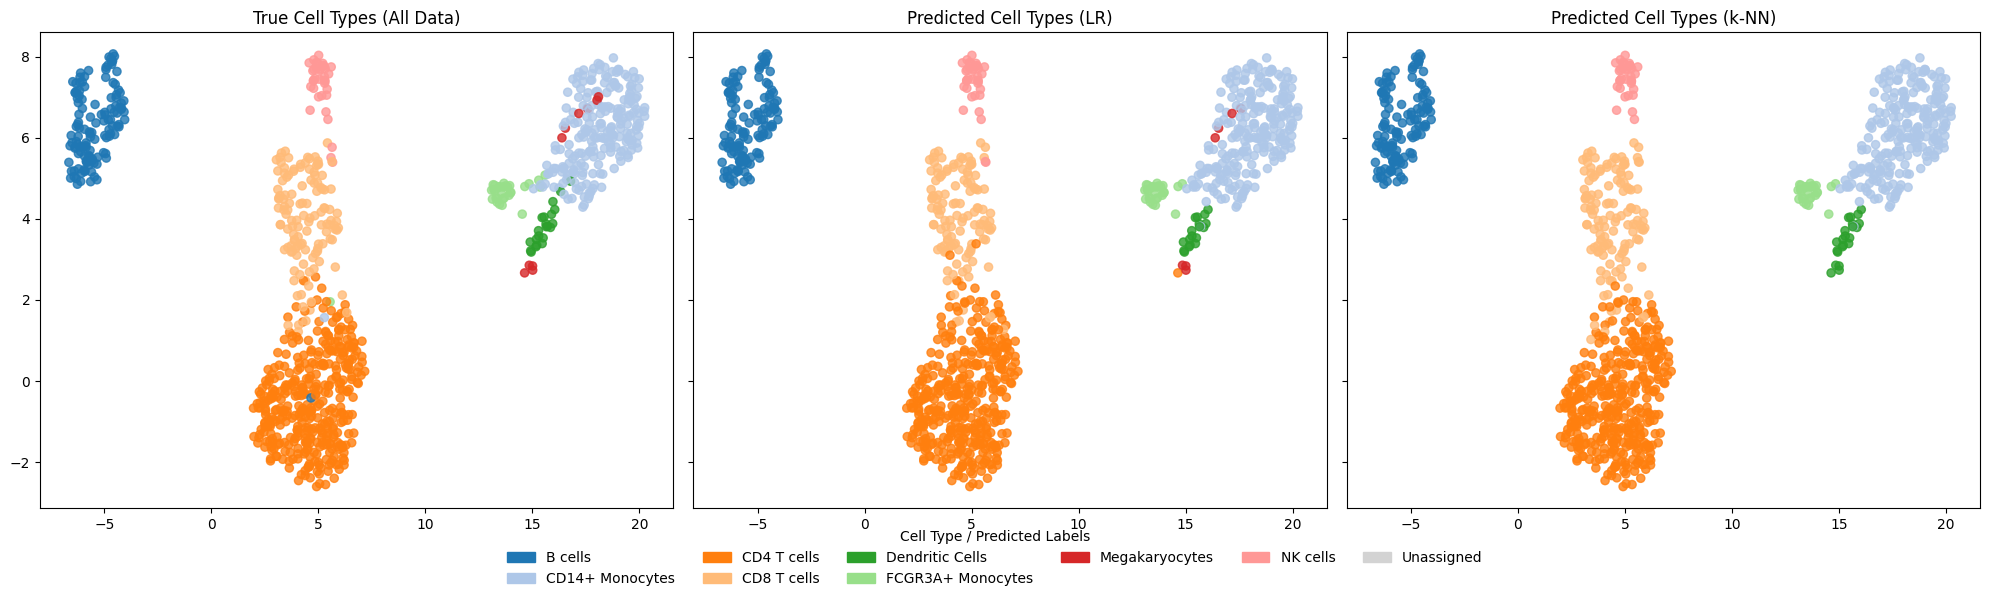

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from matplotlib.patches import Patch

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# Compute UMAP (once)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Combine all labels
all_labels = np.unique(np.concatenate([
    adata.obs["cell_type"].to_numpy(),
    adata.obs['y_pred_lr'].to_numpy(),
    adata.obs['y_pred_knn'].to_numpy()
]))

# Create consistent color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['cell_type'].map(label_to_color)
adata.obs['color_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_knn'] = adata.obs['y_pred_knn'].map(label_to_color)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
